<!--
tags: ["code generation", "debugging"]
description: |
    Use conversable language learning model agents to solve tasks and provide automatic feedback through a comprehensive example of writing, executing, and debugging Python code to compare stock price changes.
-->

# Task Solving with Code Generation, Execution and Debugging

AutoGen offers conversable LLM agents, which can be used to solve various tasks with human or automatic feedback, including tasks that require using tools via code.
Please find documentation about this feature [here](https://microsoft.github.io/autogen/docs/Use-Cases/agent_chat).

In this notebook, we demonstrate how to use `AssistantAgent` and `UserProxyAgent` to write code and execute the code. Here `AssistantAgent` is an LLM-based agent that can write Python code (in a Python coding block) for a user to execute for a given task. `UserProxyAgent` is an agent which serves as a proxy for the human user to execute the code written by `AssistantAgent`, or automatically execute the code. Depending on the setting of `human_input_mode` and `max_consecutive_auto_reply`, the `UserProxyAgent` either solicits feedback from the human user or returns auto-feedback based on the result of code execution (success or failure and corresponding outputs) to `AssistantAgent`. `AssistantAgent` will debug the code and suggest new code if the result contains error. The two agents keep communicating to each other until the task is done.

\:\:\:info Requirements

Install `pyautogen`:
```bash
pip install pyautogen
```

For more information, please refer to the [installation guide](/docs/installation/).

\:\:\:

In [1]:
from typing import Dict, Union

from IPython import get_ipython
from IPython.display import display, Image

import autogen

config_list = autogen.config_list_from_json(
    "OAI_CONFIG_LIST",
    filter_dict={
        "model": ["gpt-4"],
    },
)

\:\:\:tip

Learn more about the various ways to configure LLM endpoints [here](/docs/llm_endpoint_configuration).

\:\:\:

## Example Task: Check Stock Price Change

In the example below, let's see how to use the agents in AutoGen to write a python script and execute the script. This process involves constructing a `AssistantAgent` to serve as the assistant, along with a `UserProxyAgent` that acts as a proxy for the human user. In this example demonstrated below, when constructing the `UserProxyAgent`,  we select the `human_input_mode` to "NEVER". This means that the `UserProxyAgent` will not solicit feedback from the human user. It stops replying when the limit defined by `max_consecutive_auto_reply` is reached, or when `is_termination_msg()` returns true for the received message.

In [2]:
# create an AssistantAgent named "assistant"
assistant = autogen.AssistantAgent(
    name="assistant",
    llm_config={
        "cache_seed": 41,  # seed for caching and reproducibility
        "config_list": config_list,  # a list of OpenAI API configurations
        "temperature": 0,  # temperature for sampling
    },  # configuration for autogen's enhanced inference API which is compatible with OpenAI API
)
# create a UserProxyAgent instance named "user_proxy"
user_proxy = autogen.UserProxyAgent(
    name="user_proxy",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=10,
    is_termination_msg=lambda x: x.get("content", "").rstrip().endswith("TERMINATE"),
    code_execution_config={
        "work_dir": "coding",
        "use_docker": False,  # Please set use_docker=True if docker is available to run the generated code. Using docker is safer than running the generated code directly.
    },
)
# the assistant receives a message from the user_proxy, which contains the task description
chat_res = user_proxy.initiate_chat(
    assistant,
    message="""What date is today? Compare the year-to-date gain for META and TESLA.""",
    summary_method="reflection_with_llm",
)

user_proxy (to assistant):

What date is today? Compare the year-to-date gain for META and TESLA.

--------------------------------------------------------------------------------
assistant (to user_proxy):

First, let's get the current date using Python. 

```python
# python code
from datetime import date

# Get today's date
today = date.today()

print("Today's date:", today)
```

Next, we need to fetch the stock prices for META (Facebook) and TESLA for the current year. We can use the `yfinance` library in Python to fetch this data. If the library is not installed, it can be installed using pip:

```sh
# shell script
pip install yfinance
```

After installing the library, we can fetch the stock data:

```python
# python code
import yfinance as yf

# Get the stock data for the current year
meta_data = yf.download('META', start=str(today.year)+'-01-01', end=str(today))
tesla_data = yf.download('TSLA', start=str(today.year)+'-01-01', end=str(today))

# Calculate the year-to-date gain fo

The example above involves code execution. In AutoGen, code execution is triggered automatically by the `UserProxyAgent` when it detects an executable code block in a received message and no human user input is provided. This process occurs in a designated working directory, using a Docker container by default. Unless a specific directory is specified, AutoGen defaults to the `autogen/extensions` directory. Users have the option to specify a different working directory by setting the `work_dir` argument when constructing a new instance of the `UserProxyAgent`.

The whole chat is auto-generated.

#### Check chat results
The `initiate_chat` method returns a `ChatResult` object, which is a dataclass object storing information about the chat. Currently, it includes the following attributes:

- `chat_history`: a list of chat history.
- `summary`: a string of chat summary. A summary is only available if a summary_method is provided when initiating the chat.
- `cost`: a tuple of (total_cost, total_actual_cost), where total_cost is a dictionary of cost information, and total_actual_cost is a dictionary of information on the actual incurred cost with cache.
- `human_input`: a list of strings of human inputs solicited during the chat. (Note that since we are setting `human_input_mode` to `NEVER` in this notebook, this list is always empty.)

In [3]:
print("Chat history:", chat_res.chat_history)

print("Summary:", chat_res.summary)
print("Cost info:", chat_res.cost)

Chat history: [{'content': 'What date is today? Compare the year-to-date gain for META and TESLA.', 'role': 'assistant'}, {'content': 'First, let\'s get the current date using Python. \n\n```python\n# python code\nfrom datetime import date\n\n# Get today\'s date\ntoday = date.today()\n\nprint("Today\'s date:", today)\n```\n\nNext, we need to fetch the stock prices for META (Facebook) and TESLA for the current year. We can use the `yfinance` library in Python to fetch this data. If the library is not installed, it can be installed using pip:\n\n```sh\n# shell script\npip install yfinance\n```\n\nAfter installing the library, we can fetch the stock data:\n\n```python\n# python code\nimport yfinance as yf\n\n# Get the stock data for the current year\nmeta_data = yf.download(\'META\', start=str(today.year)+\'-01-01\', end=str(today))\ntesla_data = yf.download(\'TSLA\', start=str(today.year)+\'-01-01\', end=str(today))\n\n# Calculate the year-to-date gain for each stock\nmeta_gain = (meta_d

## Example Task: Plot Chart

In [4]:
# followup of the previous question
chat_res = user_proxy.send(
    recipient=assistant,
    message="""Plot a chart of their stock price change YTD and save to stock_price_ytd.png.""",
)

user_proxy (to assistant):

Plot a chart of their stock price change YTD and save to stock_price_ytd.png.

--------------------------------------------------------------------------------
assistant (to user_proxy):

Sure, we can use the matplotlib library in Python to plot the chart. If the library is not installed, it can be installed using pip:

```sh
# shell script
pip install matplotlib
```

After installing the library, we can plot the chart and save it:

```python
# python code
import matplotlib.pyplot as plt

# Plot the closing prices of META and TESLA
plt.figure(figsize=(14,7))
plt.plot(meta_data['Close'], label='META')
plt.plot(tesla_data['Close'], label='TESLA')
plt.title('Year-to-Date Stock Price Change for META and TESLA')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()

# Save the plot to a file
plt.savefig('stock_price_ytd.png')
```

This code will create a line chart showing the closing prices of META and TESLA from the start of the year to the current date. 

In [5]:
print("Chat history:", chat_res.chat_history)
print("Summary:", chat_res.summary)
print("Cost info:", chat_res.cost)

Chat history: [{'content': 'What date is today? Compare the year-to-date gain for META and TESLA.', 'role': 'assistant'}, {'content': 'First, let\'s get the current date using Python. \n\n```python\n# python code\nfrom datetime import date\n\n# Get today\'s date\ntoday = date.today()\n\nprint("Today\'s date:", today)\n```\n\nNext, we need to fetch the stock prices for META (Facebook) and TESLA for the current year. We can use the `yfinance` library in Python to fetch this data. If the library is not installed, it can be installed using pip:\n\n```sh\n# shell script\npip install yfinance\n```\n\nAfter installing the library, we can fetch the stock data:\n\n```python\n# python code\nimport yfinance as yf\n\n# Get the stock data for the current year\nmeta_data = yf.download(\'META\', start=str(today.year)+\'-01-01\', end=str(today))\ntesla_data = yf.download(\'TSLA\', start=str(today.year)+\'-01-01\', end=str(today))\n\n# Calculate the year-to-date gain for each stock\nmeta_gain = (meta_d

Let's display the generated figure.

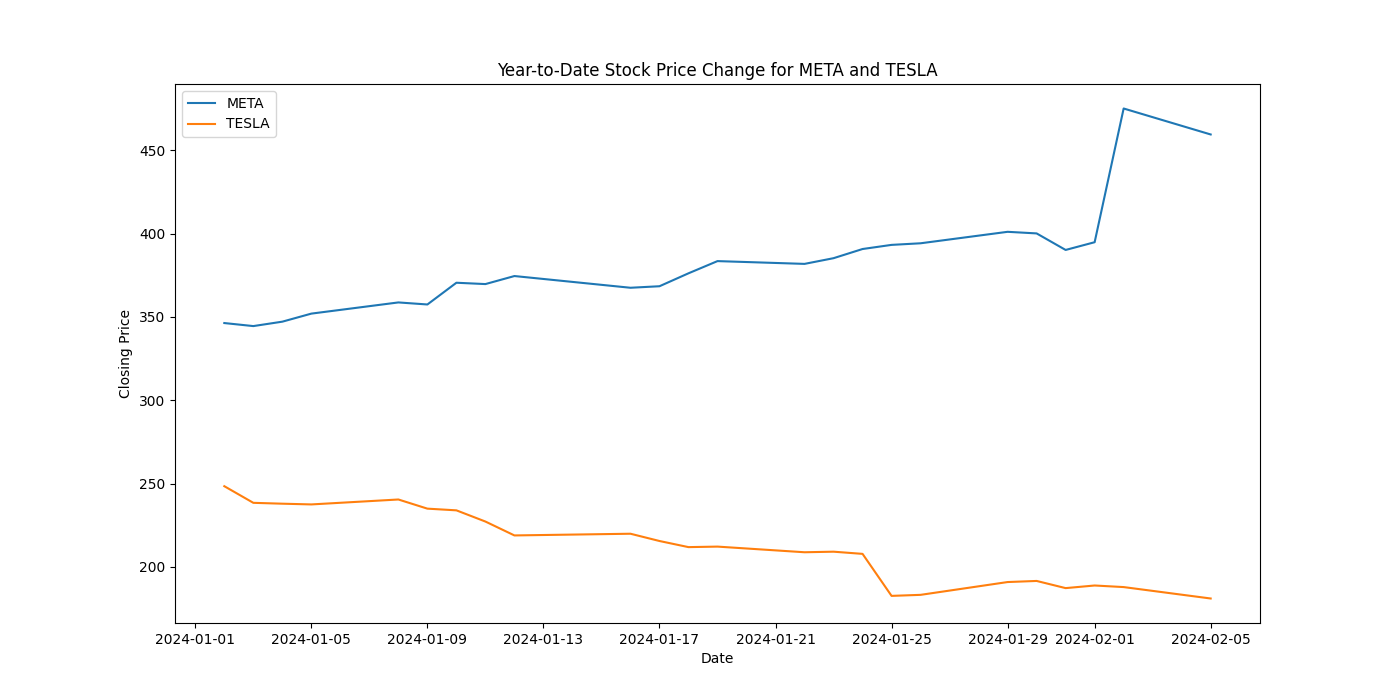

In [6]:
try:
    image = Image(filename="coding/stock_price_ytd.png")
    display(image)
except FileNotFoundError:
    print("Image not found. Please check the file name and modify if necessary.")

## Use a Different Code Execution Environment

The code execution happened in a separate process, so the plot is not directly displayed in the notebook. Is it possible to change the code execution environment into IPython?

Yes! In the following we demonstrate how to extend the `UserProxyAgent` to use a different code execution environment.

In [7]:
class IPythonUserProxyAgent(autogen.UserProxyAgent):
    def __init__(self, name: str, **kwargs):
        super().__init__(name, **kwargs)
        self._ipython = get_ipython()

    def generate_init_message(self, *args, **kwargs) -> Union[str, Dict]:
        return (
            super().generate_init_message(*args, **kwargs)
            + """
If you suggest code, the code will be executed in IPython."""
        )

    def run_code(self, code, **kwargs):
        result = self._ipython.run_cell("%%capture --no-display cap\n" + code)
        log = self._ipython.ev("cap.stdout")
        log += self._ipython.ev("cap.stderr")
        if result.result is not None:
            log += str(result.result)
        exitcode = 0 if result.success else 1
        if result.error_before_exec is not None:
            log += f"\n{result.error_before_exec}"
            exitcode = 1
        if result.error_in_exec is not None:
            log += f"\n{result.error_in_exec}"
            exitcode = 1
        return exitcode, log, None

The implementation overrides three functions in `UserProxyAgent`:
* constructor. We get the ipython instance as the code execution environment.
* `generate_init_message`. We generate a modified initial message to send to the assistant agent, by adding the info that the execution will be performed in IPython.
* `run_code`. We execute the code with the ipython instance.

With the new `IPythonUserProxyAgent`, we are able to run the code within the current notebook environment and display the plot directly.

ipython_user_proxy (to assistant):

Plot a chart of META and TESLA stock price gain YTD
If you suggest code, the code will be executed in IPython.

--------------------------------------------------------------------------------
assistant (to ipython_user_proxy):

Sure, we can use the `yfinance` library in Python to download the stock price data for META (Facebook) and TESLA. Then, we can use `matplotlib` to plot the data.

Here is the Python code to do this:

```python
# Python code block
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# Download historical data as dataframe
meta = yf.download('FB', start='2022-01-01', end=pd.to_datetime('today').strftime('%Y-%m-%d'))
tesla = yf.download('TSLA', start='2022-01-01', end=pd.to_datetime('today').strftime('%Y-%m-%d'))

# Calculate the YTD return
meta['YTD'] = (meta['Adj Close'] / meta['Adj Close'][0]) - 1
tesla['YTD'] = (tesla['Adj Close'] / tesla['Adj Close'][0]) - 1

# Plot the YTD return
plt.figure(figsize=(1

IndexError: index 0 is out of bounds for axis 0 with size 0


>>>>>>>> EXECUTING CODE BLOCK 1 (inferred language is python)...
ipython_user_proxy (to assistant):

exitcode: 0 (execution succeeded)
Code output: 
[*********************100%%**********************]  1 of 1 completed

1 Failed download:
['FB']: Exception('%ticker%: No timezone found, symbol may be delisted')
/home/jason/dl_env/lib/python3.10/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
[*********************100%%**********************]  1 of 1 completed
/tmp/ipykernel_54901/1880045307.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  meta['YTD'] = (meta['Adj Close'] / meta['Adj Close'][0]) - 1



-------

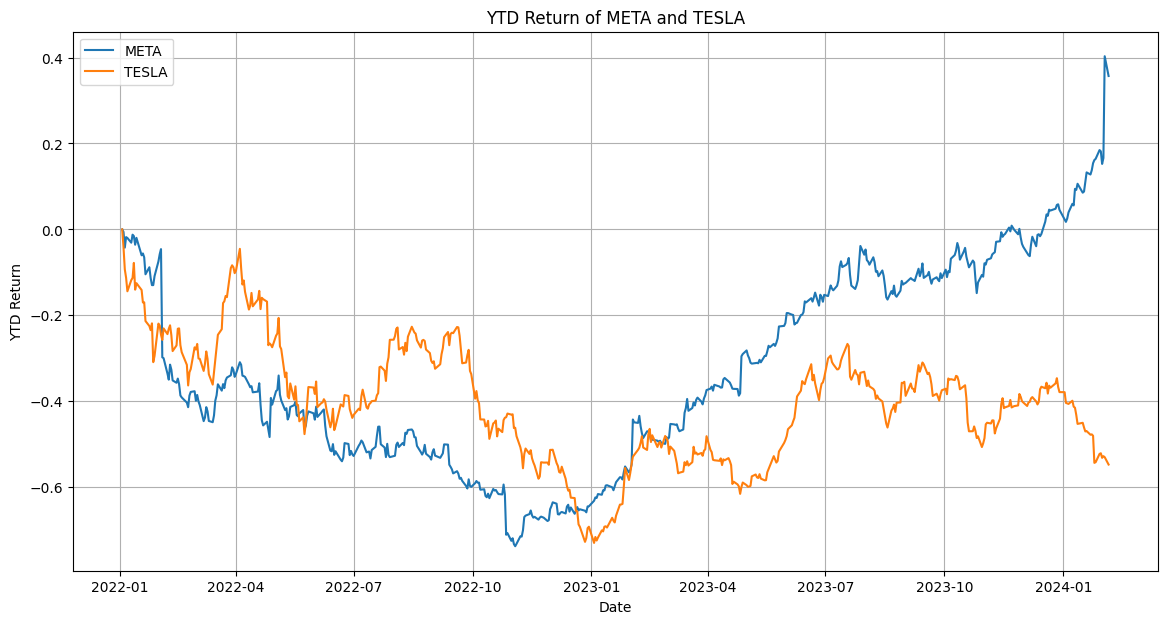

ipython_user_proxy (to assistant):

exitcode: 0 (execution succeeded)
Code output: 
/home/jason/dl_env/lib/python3.10/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
[*********************100%%**********************]  1 of 1 completed
/home/jason/dl_env/lib/python3.10/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
[*********************100%%**********************]  1 of 1 completed
/tmp/ipykernel_54901/1659753067.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To acces

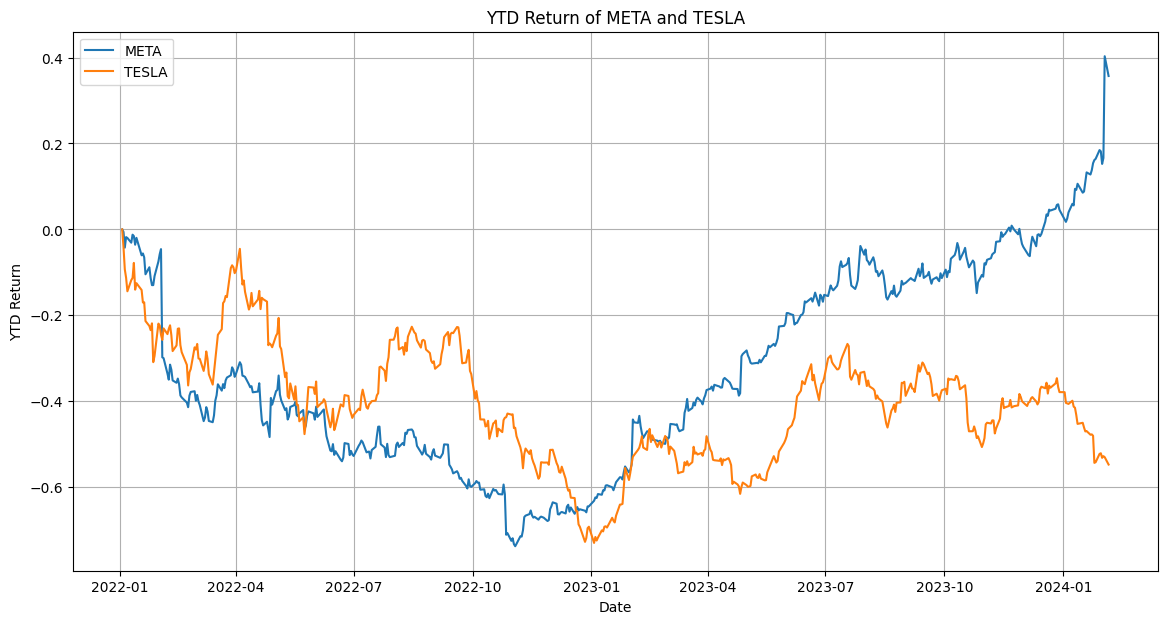

ipython_user_proxy (to assistant):

exitcode: 0 (execution succeeded)
Code output: 
/home/jason/dl_env/lib/python3.10/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
[*********************100%%**********************]  1 of 1 completed
/home/jason/dl_env/lib/python3.10/site-packages/yfinance/utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
[*********************100%%**********************]  1 of 1 completed


--------------------------------------------------------------------------------
assistant (to ipython_user_proxy):

Great! The code executed successfully and the warnings are gone. The code should have plotted a chart showing

/home/jason/dl_env/lib/python3.10/site-packages/autogen/agentchat/conversable_agent.py:838: UserWarning: No summary_method provided or summary_method is not supported: 
  warnings.warn("No summary_method provided or summary_method is not supported: ")


ChatResult(chat_history=[{'content': 'Plot a chart of META and TESLA stock price gain YTD\nIf you suggest code, the code will be executed in IPython.', 'role': 'assistant'}, {'content': "Sure, we can use the `yfinance` library in Python to download the stock price data for META (Facebook) and TESLA. Then, we can use `matplotlib` to plot the data.\n\nHere is the Python code to do this:\n\n```python\n# Python code block\nimport yfinance as yf\nimport matplotlib.pyplot as plt\nimport pandas as pd\n\n# Download historical data as dataframe\nmeta = yf.download('FB', start='2022-01-01', end=pd.to_datetime('today').strftime('%Y-%m-%d'))\ntesla = yf.download('TSLA', start='2022-01-01', end=pd.to_datetime('today').strftime('%Y-%m-%d'))\n\n# Calculate the YTD return\nmeta['YTD'] = (meta['Adj Close'] / meta['Adj Close'][0]) - 1\ntesla['YTD'] = (tesla['Adj Close'] / tesla['Adj Close'][0]) - 1\n\n# Plot the YTD return\nplt.figure(figsize=(14,7))\nplt.plot(meta['YTD'], label='META')\nplt.plot(tesla[

In [8]:
ipy_user = IPythonUserProxyAgent(
    "ipython_user_proxy",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=10,
    is_termination_msg=lambda x: x.get("content", "").rstrip().endswith("TERMINATE")
    or x.get("content", "").rstrip().endswith('"TERMINATE".'),
    code_execution_config={
        "use_docker": False,  # Please set use_docker=True if docker is available to run the generated code. Using docker is safer than running the generated code directly.
    },
)
# the assistant receives a message from the user, which contains the task description
ipy_user.initiate_chat(
    assistant,
    message="""Plot a chart of META and TESLA stock price gain YTD""",
)